### B3: Technical Indicator + Fundamnetal indicator + sector + transcript sentiment

In [2]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [3]:
# ── Tech modeling table ───────────────────────────────────────────────────
tech_path = "data/tech_modeling_table.parquet"
df_tech   = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

# ── Fundamental features ──────────────────────────────────────────────────
fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund   = pl.read_parquet(fund_path)

df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq",
    "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
])

# ── FinBERT transcript sentiment ──────────────────────────────────────────
df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob",
    "neg_prob",
])
print(f"FinBERT shape: {df_finbert.shape}")

# ── Merge onto tech table ─────────────────────────────────────────────────
df_model = df_tech.join(df_fund,    on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")

print(f"Combined table shape: {df_model.shape}")
print(f"Target: {df_model['target_direction'].mean():.1%} positive")
print(f"\nNull counts for sentiment cols:")
print(df_model.select(["pos_prob", "neg_prob"]).null_count())

Tech table shape: (24048, 225)
FinBERT shape: (24294, 4)
Combined table shape: (24048, 237)
Target: 52.4% positive

Null counts for sentiment cols:
shape: (1, 2)
┌──────────┬──────────┐
│ pos_prob ┆ neg_prob │
│ ---      ┆ ---      │
│ u32      ┆ u32      │
╞══════════╪══════════╡
│ 0        ┆ 0        │
└──────────┴──────────┘


In [4]:
print(df_model.select(["pos_prob", "neg_prob"]))

shape: (24_048, 2)
┌──────────┬──────────┐
│ pos_prob ┆ neg_prob │
│ ---      ┆ ---      │
│ f64      ┆ f64      │
╞══════════╪══════════╡
│ 0.699104 ┆ 0.274711 │
│ 0.398258 ┆ 0.32738  │
│ 0.553552 ┆ 0.402583 │
│ 0.69333  ┆ 0.245209 │
│ 0.788716 ┆ 0.176522 │
│ …        ┆ …        │
│ 0.549015 ┆ 0.378318 │
│ 0.524169 ┆ 0.41728  │
│ 0.492895 ┆ 0.425231 │
│ 0.467151 ┆ 0.357038 │
│ 0.304987 ┆ 0.402945 │
└──────────┴──────────┘


In [5]:
# Source sector from FinBERT parquet (has symbol → sector mapping)
df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector     = df_sector_raw.select(["symbol", "sector"]).unique()

df_sector = df_sector.with_columns(
    pl.col("sector").fill_null("Unknown")
)

sectors   = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")

print(f"Sectors: {sectors}")
print(f"Unique symbols in sector map: {df_sector.shape[0]}")

df_model = df_model.join(df_sector, on="symbol", how="left")

sector_cols = [c for c in df_model.columns if c.startswith("sector_")]
print(f"Shape after sector join: {df_model.shape}")
print(f"Sector columns: {sector_cols}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Unique symbols in sector map: 503
Shape after sector join: (24048, 249)
Sector columns: ['sector_Basic_Materials', 'sector_Communication_Services', 'sector_Consumer_Cyclical', 'sector_Consumer_Defensive', 'sector_Energy', 'sector_Financial_Services', 'sector_Healthcare', 'sector_Industrials', 'sector_Real_Estate', 'sector_Technology', 'sector_Unknown', 'sector_Utilities']


In [6]:
TRAIN_WINDOW = 7
FOLDS = [
    (date(y - TRAIN_WINDOW, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

# entry_price, max_high, min_high, max_day, min_day must be excluded —
# they either leak target construction or are metadata, not features
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_direction", "max_high", "min_high", "max_day", "min_day",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

folds_data = []

for fold_num, (train_start, test_start, test_end) in enumerate(FOLDS, 1):
    train = df_model.filter(
        (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
    )
    test = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test  = test.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer  = SimpleImputer(strategy="median")
    X_train  = imputer.fit_transform(X_train)
    X_test   = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "train_years": f"{train_start.year}-{test_start.year - 1}",
        "test_year":   test_start.year,
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls":  test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret":  test["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num}: train [{train_start.year}-{test_start.year-1}] "
          f"({len(X_train):,}) → test [{test_start.year}] ({len(X_test):,})")

Total features: 240
Fold 1: train [2014-2020] (13,169) → test [2021] (1,970)
Fold 2: train [2015-2021] (13,313) → test [2022] (1,975)
Fold 3: train [2016-2022] (13,439) → test [2023] (1,984)
Fold 4: train [2017-2023] (13,560) → test [2024] (2,000)
Fold 5: train [2018-2024] (13,671) → test [2025] (2,008)


In [7]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_dir = np.random.randint(0, 2, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_dir)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_dir)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nAvg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.4904
Fold 2: DA=0.5068
Fold 3: DA=0.5040
Fold 4: DA=0.4935
Fold 5: DA=0.5030

Avg DA:   0.4995
Avg MAE:  0.0310
Avg RMSE: 0.0458


In [12]:
lr_clf   = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(lr_clf['true']), np.array(lr_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(lr_clf['true']), np.array(lr_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5711
Fold 2 [2022]: DA=0.6106
Fold 3 [2023]: DA=0.5852
Fold 4 [2024]: DA=0.5365
Fold 5 [2025]: DA=0.5707

Avg DA:     0.5748
Pooled F1:  0.5761
Pooled AUC: 0.6051


In [13]:
linreg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
linreg_model = LinearRegression()

for f in folds_data:
    linreg_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = linreg_model.predict(f["X_test_sc"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    linreg["fold_mae"].append(mae)
    linreg["fold_rmse"].append(rmse)
    linreg["preds"].extend(preds)
    linreg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(linreg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(linreg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(linreg['true']), np.array(linreg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0287  RMSE=0.0410
Fold 2 [2022]: MAE=0.0358  RMSE=0.0507
Fold 3 [2023]: MAE=0.0277  RMSE=0.0394
Fold 4 [2024]: MAE=0.0329  RMSE=0.1692
Fold 5 [2025]: MAE=0.0500  RMSE=0.8718

Avg MAE:   0.0350
Avg RMSE:  0.2344
Pooled R²: -75.6572


In [14]:
rf_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(
    n_estimators=100, max_depth=15, class_weight="balanced",
    random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(rf_clf['true']), np.array(rf_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(rf_clf['true']), np.array(rf_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5802
Fold 2 [2022]: DA=0.6273
Fold 3 [2023]: DA=0.5902
Fold 4 [2024]: DA=0.5340
Fold 5 [2025]: DA=0.6011

Avg DA:     0.5866
Pooled F1:  0.5846
Pooled AUC: 0.6150


In [15]:
rf_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
rf_reg_model = RandomForestRegressor(
    n_estimators=100, max_depth=15, random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0279  RMSE=0.0396
Fold 2 [2022]: MAE=0.0352  RMSE=0.0483
Fold 3 [2023]: MAE=0.0262  RMSE=0.0364
Fold 4 [2024]: MAE=0.0285  RMSE=0.0442
Fold 5 [2025]: MAE=0.0299  RMSE=0.0440

Avg MAE:   0.0295
Avg RMSE:  0.0425
Pooled R²: 0.1288


In [16]:
xgb_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(xgb_clf['true']), np.array(xgb_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(xgb_clf['true']), np.array(xgb_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5807
Fold 2 [2022]: DA=0.6167
Fold 3 [2023]: DA=0.5529
Fold 4 [2024]: DA=0.5335
Fold 5 [2025]: DA=0.5637

Avg DA:     0.5695
Pooled F1:  0.5656
Pooled AUC: 0.5856


In [17]:
xgb_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(n_estimators=200, random_state=42)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0294  RMSE=0.0421
Fold 2 [2022]: MAE=0.0379  RMSE=0.0519
Fold 3 [2023]: MAE=0.0287  RMSE=0.0401
Fold 4 [2024]: MAE=0.0301  RMSE=0.0462
Fold 5 [2025]: MAE=0.0327  RMSE=0.0478

Avg MAE:   0.0318
Avg RMSE:  0.0456
Pooled R²: -0.0031


In [18]:
print("=== Direction (Classification) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Prec':>8} {'Recall':>8} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf), ("XGBoost", xgb_clf)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1   = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec  = recall_score(true, preds, average="weighted")
    auc_str = (f"{roc_auc_score(true, np.array(r['probs'])):>8.4f}"
               if r.get("probs") else f"{'—':>8}")
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>8.4f} {rec:>8.4f} {auc_str}")

print(f"\n=== Magnitude (Regression) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Linear Regression", linreg),
                ("Random Forest", rf_reg), ("XGBoost", xgb_reg)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} "
          f"{np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Direction (Classification) ===
Model                        Avg DA%  Pooled F1     Prec   Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.4995     0.5020   0.5095   0.4995        —
Logistic Regression           0.5748     0.5761   0.5785   0.5747   0.6051
Random Forest                 0.5866     0.5846   0.5835   0.5865   0.6150
XGBoost                       0.5695     0.5656   0.5642   0.5694   0.5856

=== Magnitude (Regression) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0310     0.0458    -0.0124
Linear Regression             0.0350     0.2344   -75.6572
Random Forest                 0.0295     0.0425     0.1288
XGBoost                       0.0318     0.0456    -0.0031


In [19]:
os.makedirs("models", exist_ok=True)

for name, model in [("lr_clf",  lr_model),
                    ("linreg",  linreg_model),
                    ("rf_clf",  rf_clf_model),
                    ("rf_reg",  rf_reg_model),
                    ("xgb_clf", xgb_clf_model),
                    ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, f"models/b3_{name}.pkl")
    print(f"Saved models/b3_{name}.pkl")

with open("models/b3_results.pkl", "wb") as f:
    pickle.dump({
        "clf": {"B0 Random":          b0_clf,
                "Logistic Regression": lr_clf,
                "Random Forest":       rf_clf,
                "XGBoost":             xgb_clf},
        "reg": {"B0 Mean":            b0_reg,
                "Linear Regression":   linreg,
                "Random Forest":       rf_reg,
                "XGBoost":             xgb_reg},
    }, f)
print("Saved models/b3_results.pkl")

Saved models/b3_lr_clf.pkl
Saved models/b3_linreg.pkl
Saved models/b3_rf_clf.pkl
Saved models/b3_rf_reg.pkl
Saved models/b3_xgb_clf.pkl
Saved models/b3_xgb_reg.pkl
Saved models/b3_results.pkl


In [20]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['grid.color']       = 'gray'

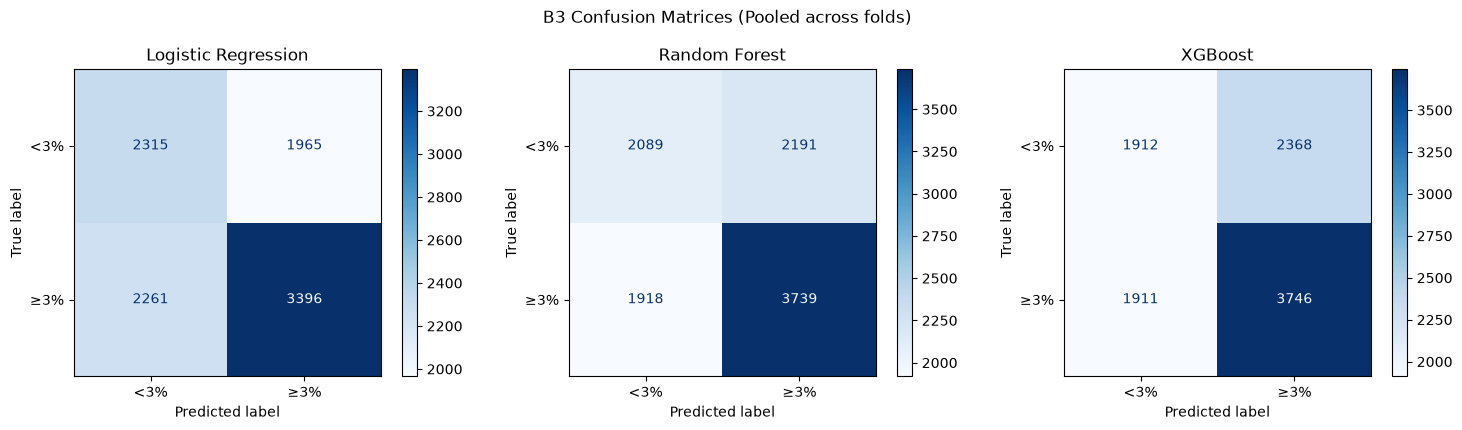

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Logistic Regression", lr_clf),
                                  ("Random Forest",       rf_clf),
                                  ("XGBoost",             xgb_clf)]):
    ConfusionMatrixDisplay.from_predictions(
        np.array(r["true"]), np.array(r["preds"]),
        ax=ax, cmap="Blues", display_labels=["<3%", "≥3%"],
    )
    ax.set_title(name)

plt.suptitle("B3 Confusion Matrices (Pooled across folds)", y=1.02)
plt.tight_layout()
plt.show()

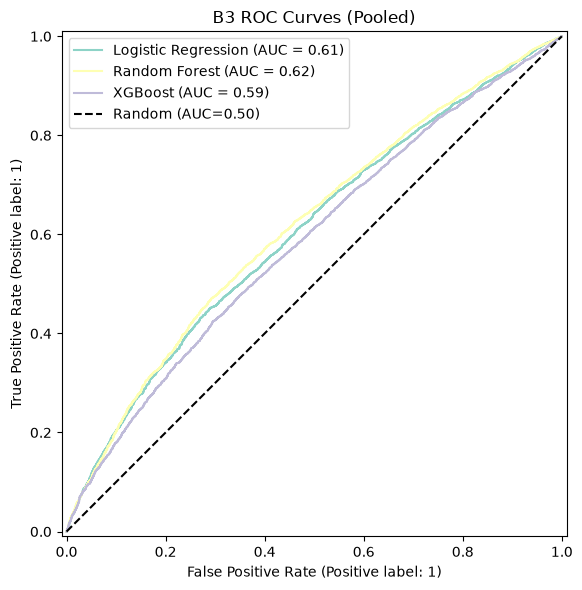

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in [("Logistic Regression", lr_clf),
                ("Random Forest",       rf_clf),
                ("XGBoost",             xgb_clf)]:
    RocCurveDisplay.from_predictions(
        np.array(r["true"]), np.array(r["probs"]), ax=ax, name=name,
    )

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.50)")
ax.set_title("B3 ROC Curves (Pooled)")
ax.legend()
plt.tight_layout()
plt.show()

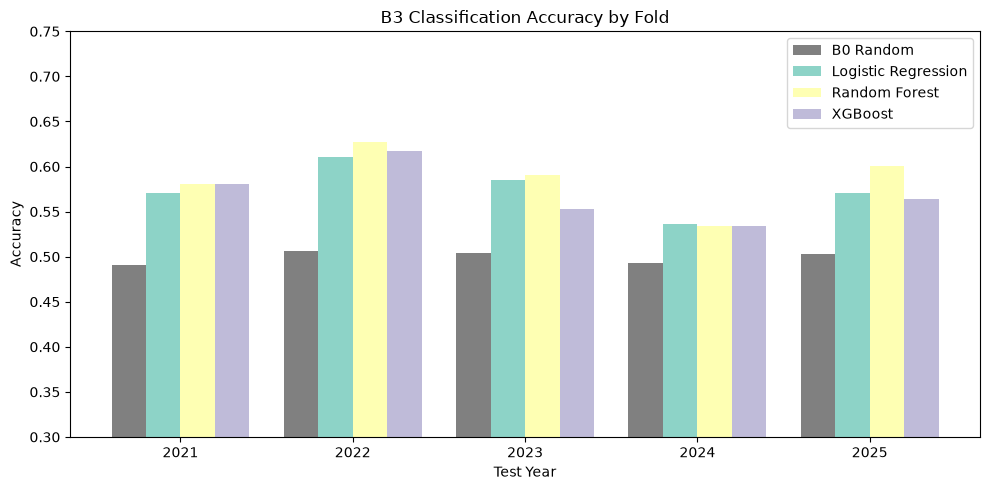

In [23]:
fold_years = [f["test_year"] for f in folds_data]
x     = np.arange(len(fold_years))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width,      b0_clf["fold_acc"],  width, label="B0 Random",          color="gray")
ax.bar(x,              lr_clf["fold_acc"],  width, label="Logistic Regression")
ax.bar(x + width,      rf_clf["fold_acc"],  width, label="Random Forest")
ax.bar(x + 2 * width, xgb_clf["fold_acc"], width, label="XGBoost")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(fold_years)
ax.set_xlabel("Test Year")
ax.set_ylabel("Accuracy")
ax.set_title("B3 Classification Accuracy by Fold")
ax.set_ylim(0.3, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

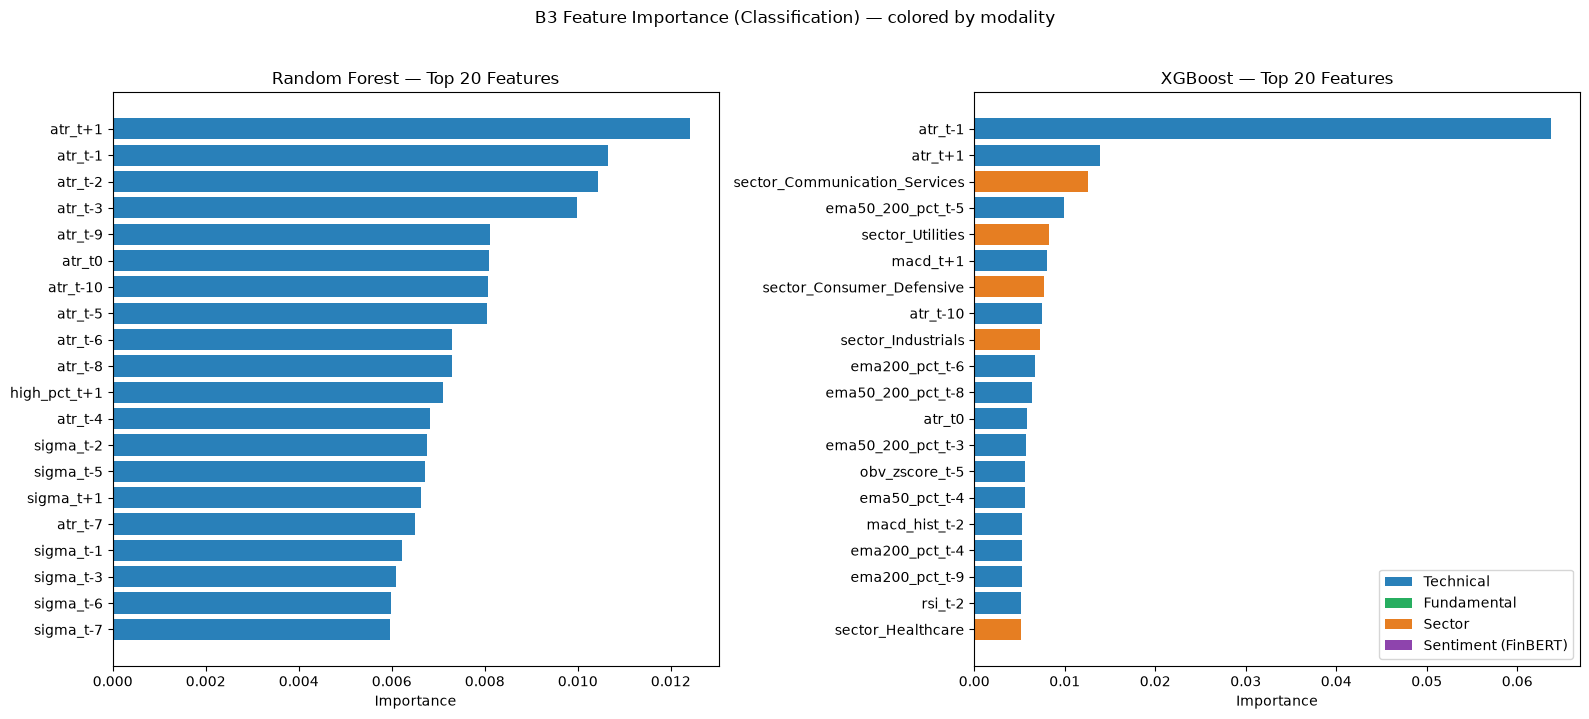

In [24]:
FUND_COLS = {
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",   "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin",     "fcf_margin_qoq",
    "roe",            "roe_qoq",
}
SENTIMENT_COLS = {"pos_prob", "neg_prob"}

def feature_color(name):
    if name.startswith("sector_"):  return "#e67e22"  # orange  — sector
    if name in FUND_COLS:           return "#27ae60"  # green   — fundamental
    if name in SENTIMENT_COLS:      return "#8e44ad"  # purple  — sentiment
    return "#2980b9"                                  # blue    — technical

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (label, imp) in zip(axes, [
    ("Random Forest", rf_clf_model.feature_importances_),
    ("XGBoost",       xgb_clf_model.feature_importances_),
]):
    top_idx   = np.argsort(imp)[-20:]
    top_names = np.array(feature_cols)[top_idx]
    top_imp   = imp[top_idx]
    colors    = [feature_color(n) for n in top_names]

    ax.barh(top_names, top_imp, color=colors)
    ax.set_title(f"{label} — Top 20 Features")
    ax.set_xlabel("Importance")

legend_elements = [
    Patch(facecolor="#2980b9", label="Technical"),
    Patch(facecolor="#27ae60", label="Fundamental"),
    Patch(facecolor="#e67e22", label="Sector"),
    Patch(facecolor="#8e44ad", label="Sentiment (FinBERT)"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

plt.suptitle("B3 Feature Importance (Classification) — colored by modality", y=1.02)
plt.tight_layout()
plt.show()

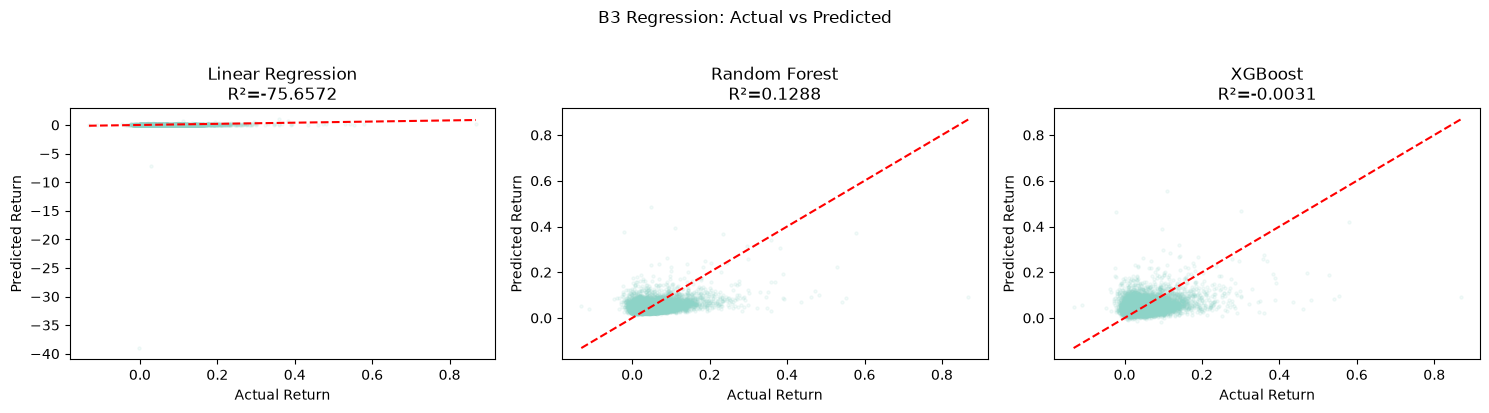

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Linear Regression", linreg),
                                  ("Random Forest",     rf_reg),
                                  ("XGBoost",           xgb_reg)]):
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    ax.scatter(true, preds, alpha=0.1, s=5)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], "r--")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{name}\nR²={r2_score(true, preds):.4f}")

plt.suptitle("B3 Regression: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

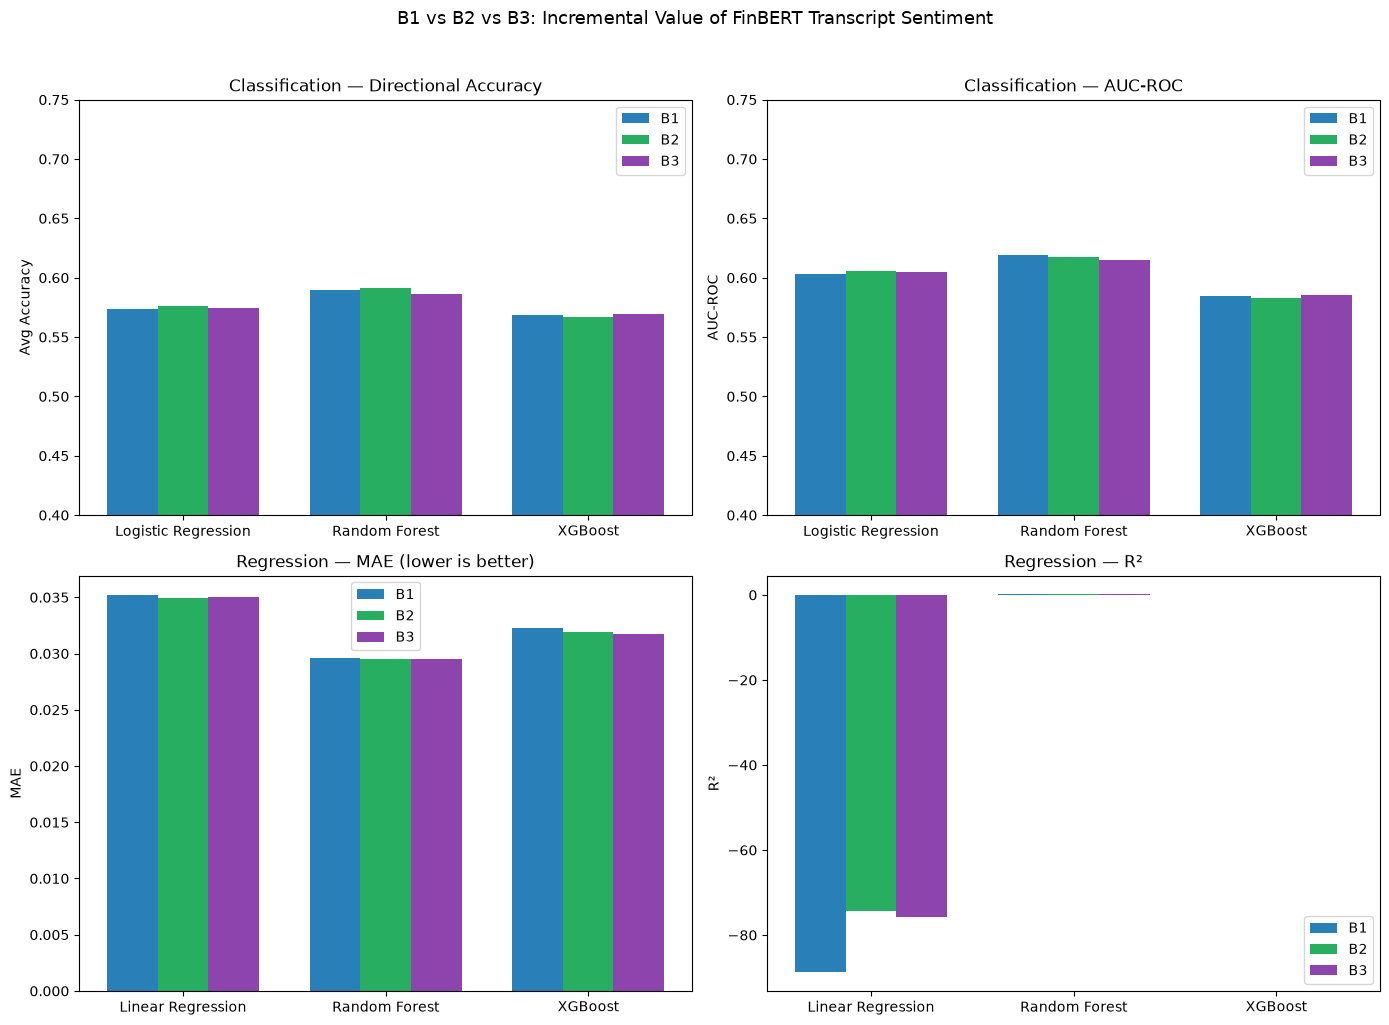

In [26]:
with open("models/b1_results.pkl", "rb") as f:
    b1 = pickle.load(f)
with open("models/b2_results.pkl", "rb") as f:
    b2 = pickle.load(f)

b3 = {
    "clf": {"Logistic Regression": lr_clf,  "Random Forest": rf_clf,  "XGBoost": xgb_clf},
    "reg": {"Linear Regression":   linreg,  "Random Forest": rf_reg,  "XGBoost": xgb_reg},
}

clf_models = ["Logistic Regression", "Random Forest", "XGBoost"]
reg_models = ["Linear Regression",   "Random Forest", "XGBoost"]

def clf_da(res, m):  return np.mean(res["clf"][m]["fold_acc"])
def clf_auc(res, m): return roc_auc_score(np.array(res["clf"][m]["true"]),
                                           np.array(res["clf"][m]["probs"]))
def reg_mae(res, m): return np.mean(res["reg"][m]["fold_mae"])
def reg_r2(res, m):  return r2_score(np.array(res["reg"][m]["true"]),
                                      np.array(res["reg"][m]["preds"]))

x     = np.arange(3)
width = 0.25
colors = {"B1": "#2980b9", "B2": "#27ae60", "B3": "#8e44ad"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Classification DA ──────────────────────────────────────────────────────
ax = axes[0, 0]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [clf_da(res, m) for m in clf_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(clf_models)
ax.set_ylabel("Avg Accuracy")
ax.set_title("Classification — Directional Accuracy")
ax.set_ylim(0.4, 0.75); ax.legend()

# ── Classification AUC ─────────────────────────────────────────────────────
ax = axes[0, 1]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [clf_auc(res, m) for m in clf_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(clf_models)
ax.set_ylabel("AUC-ROC")
ax.set_title("Classification — AUC-ROC")
ax.set_ylim(0.4, 0.75); ax.legend()

# ── Regression MAE ─────────────────────────────────────────────────────────
ax = axes[1, 0]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [reg_mae(res, m) for m in reg_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(reg_models)
ax.set_ylabel("MAE")
ax.set_title("Regression — MAE (lower is better)")
ax.legend()

# ── Regression R² ──────────────────────────────────────────────────────────
ax = axes[1, 1]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [reg_r2(res, m) for m in reg_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(reg_models)
ax.set_ylabel("R²")
ax.set_title("Regression — R²")
ax.legend()

plt.suptitle("B1 vs B2 vs B3: Incremental Value of FinBERT Transcript Sentiment",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()